processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_32566/1149981826.py:92: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_32566/1149981826.py:116: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


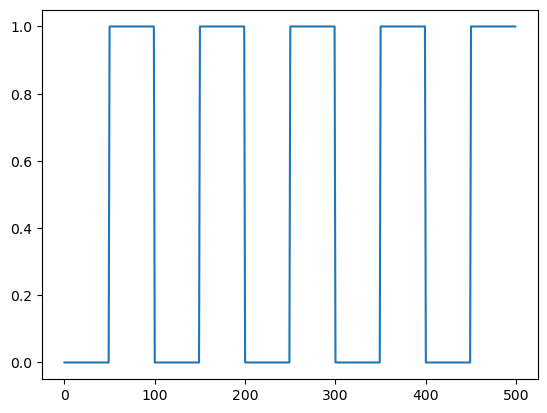

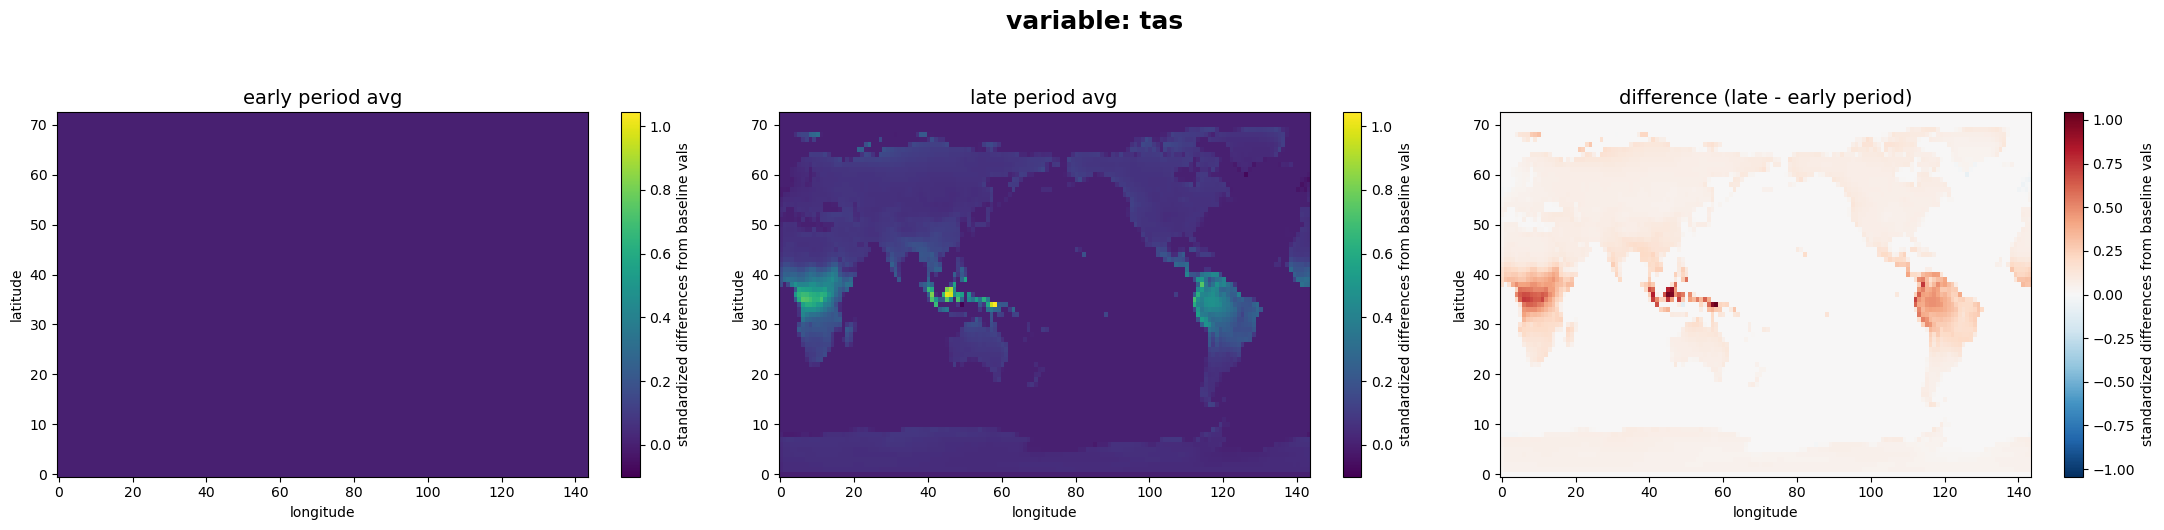

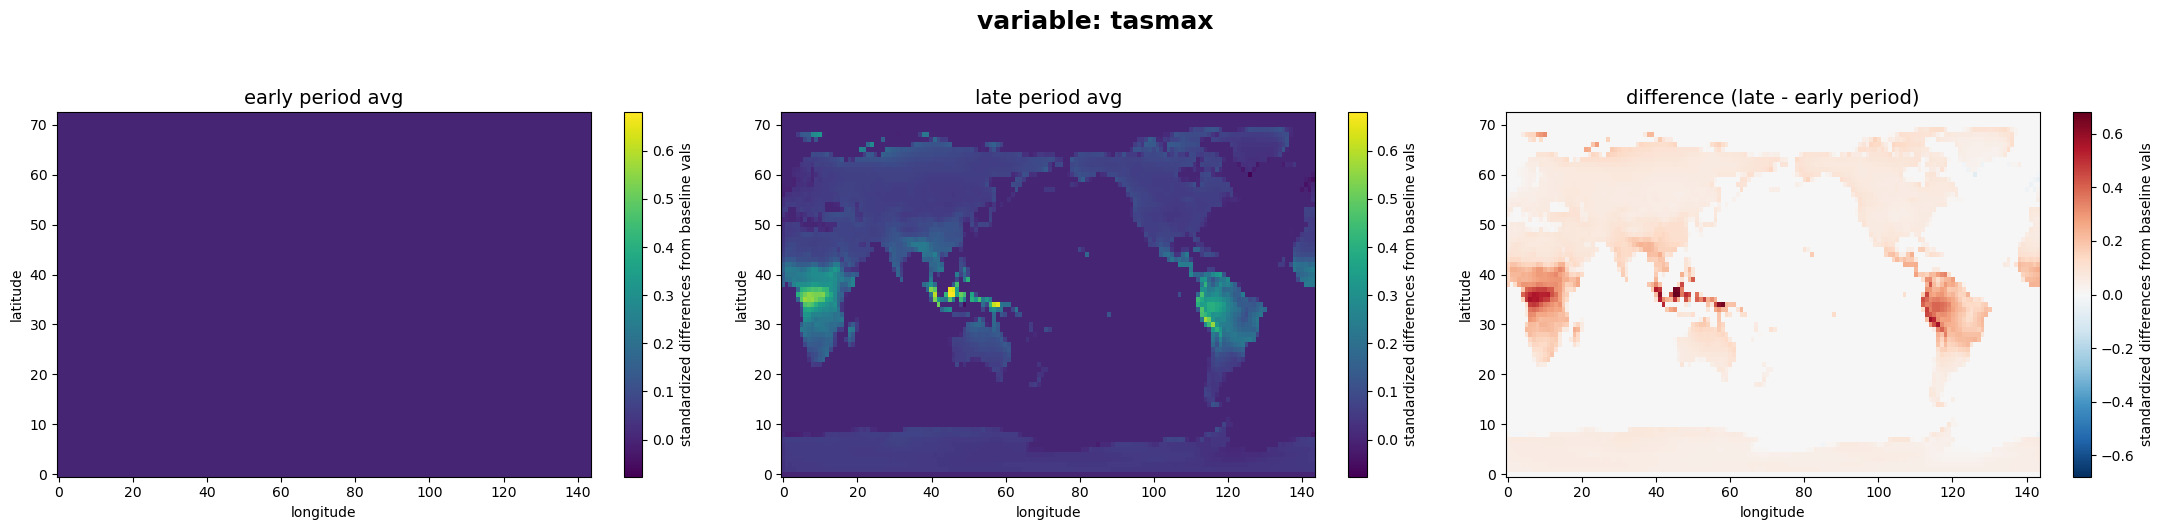

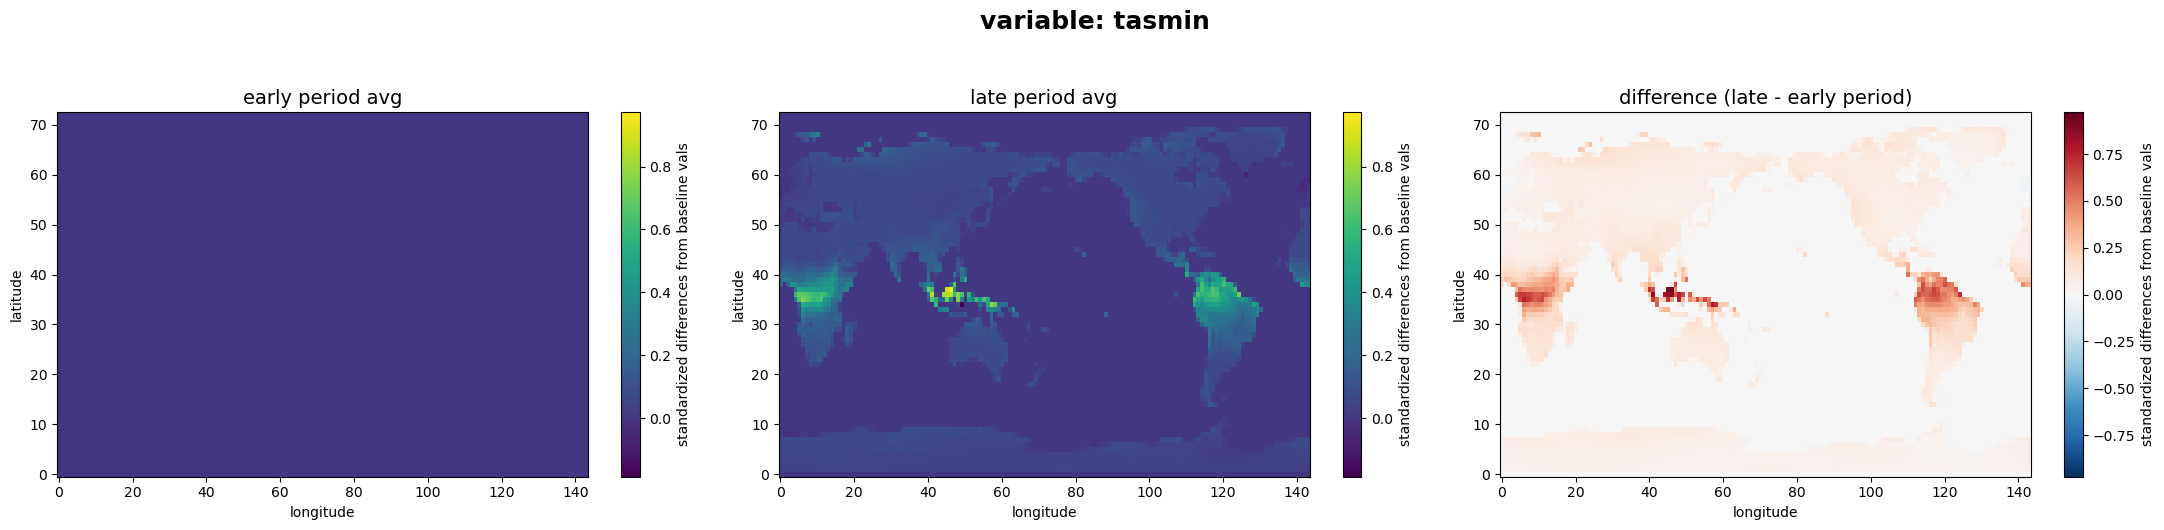

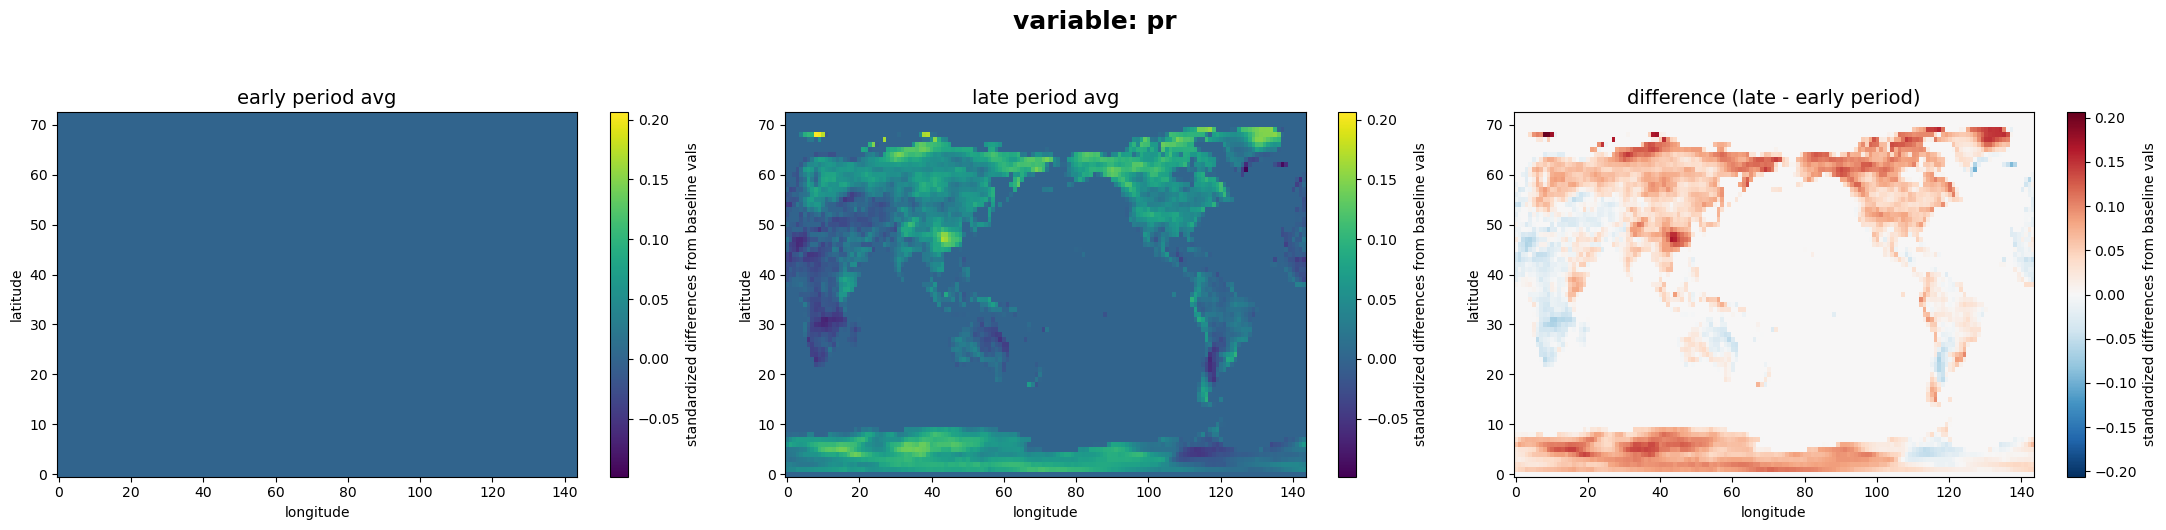

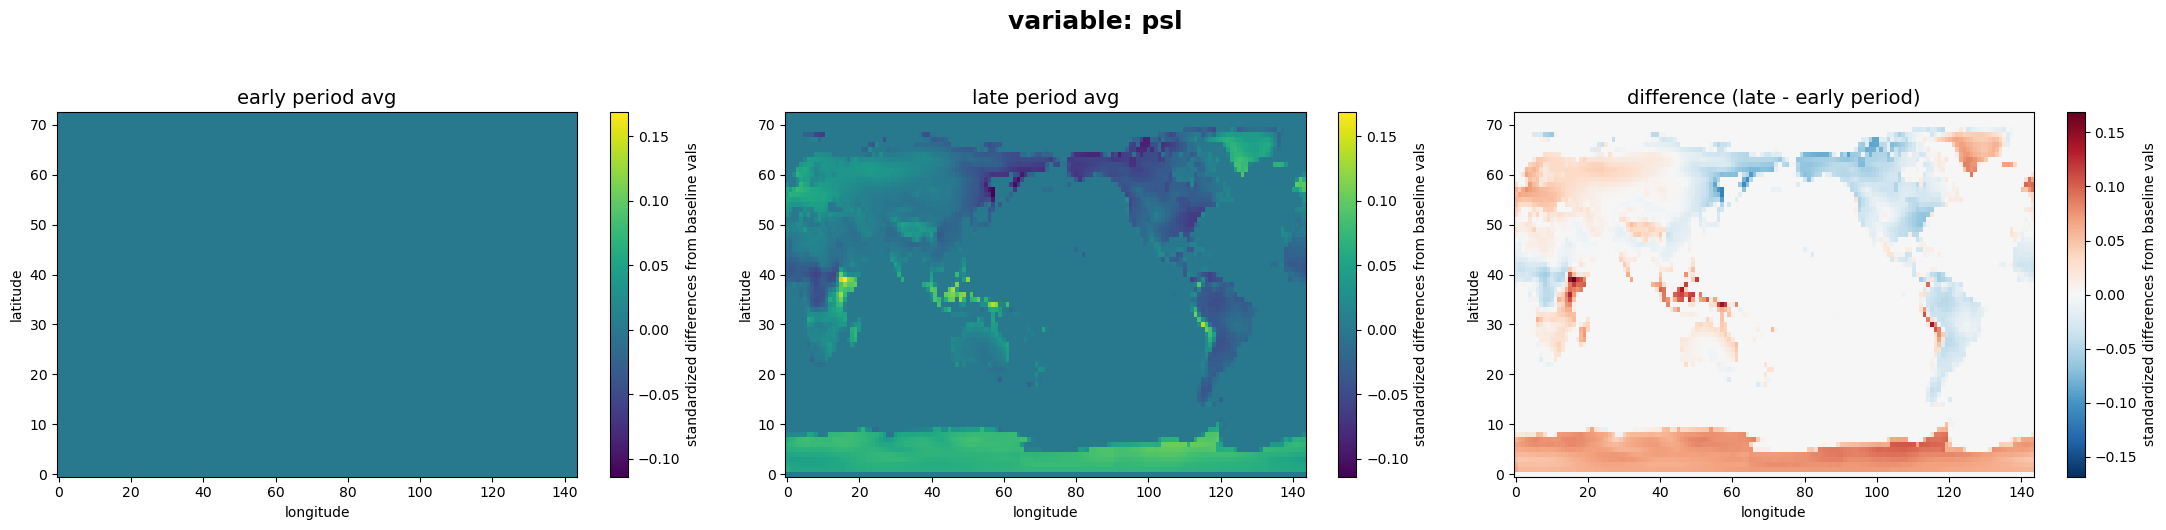

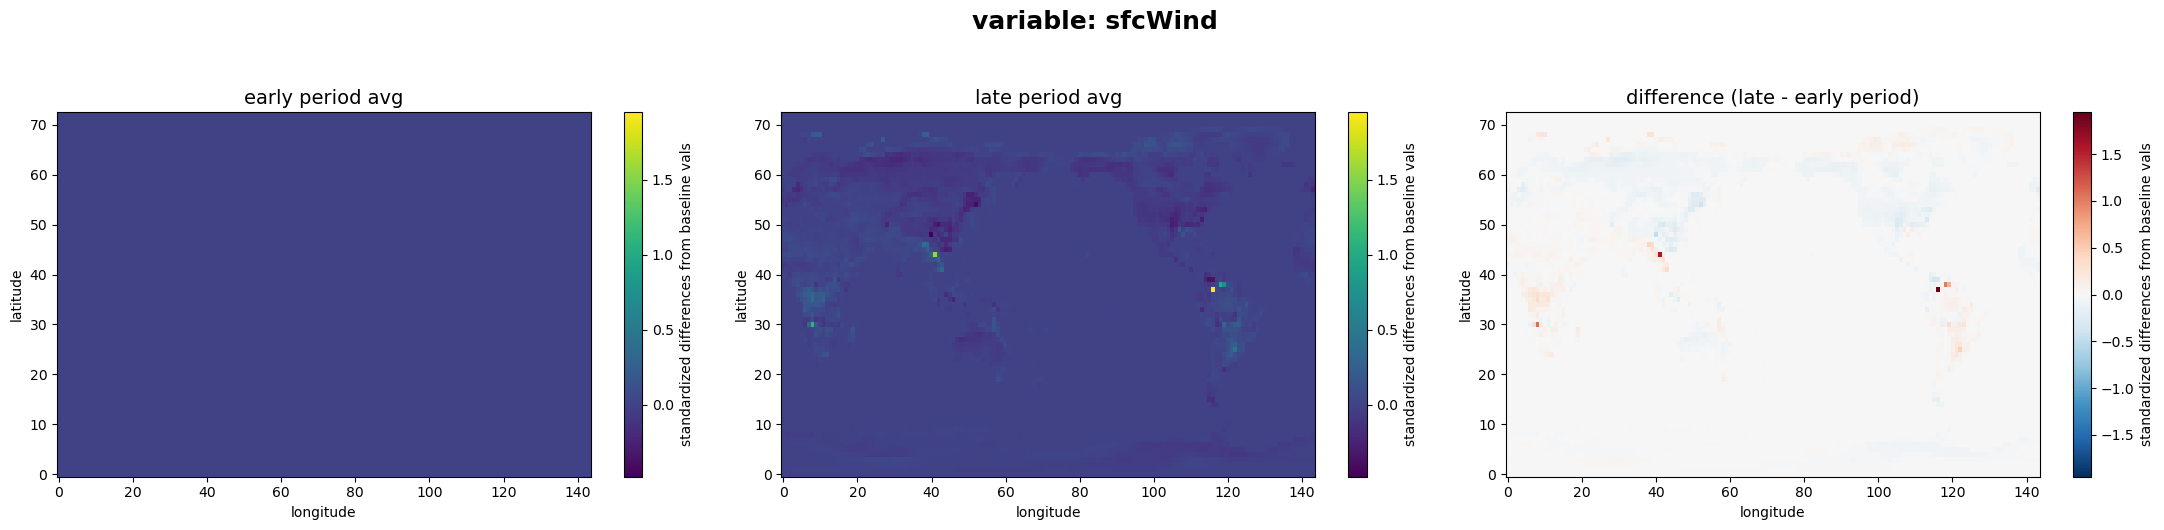

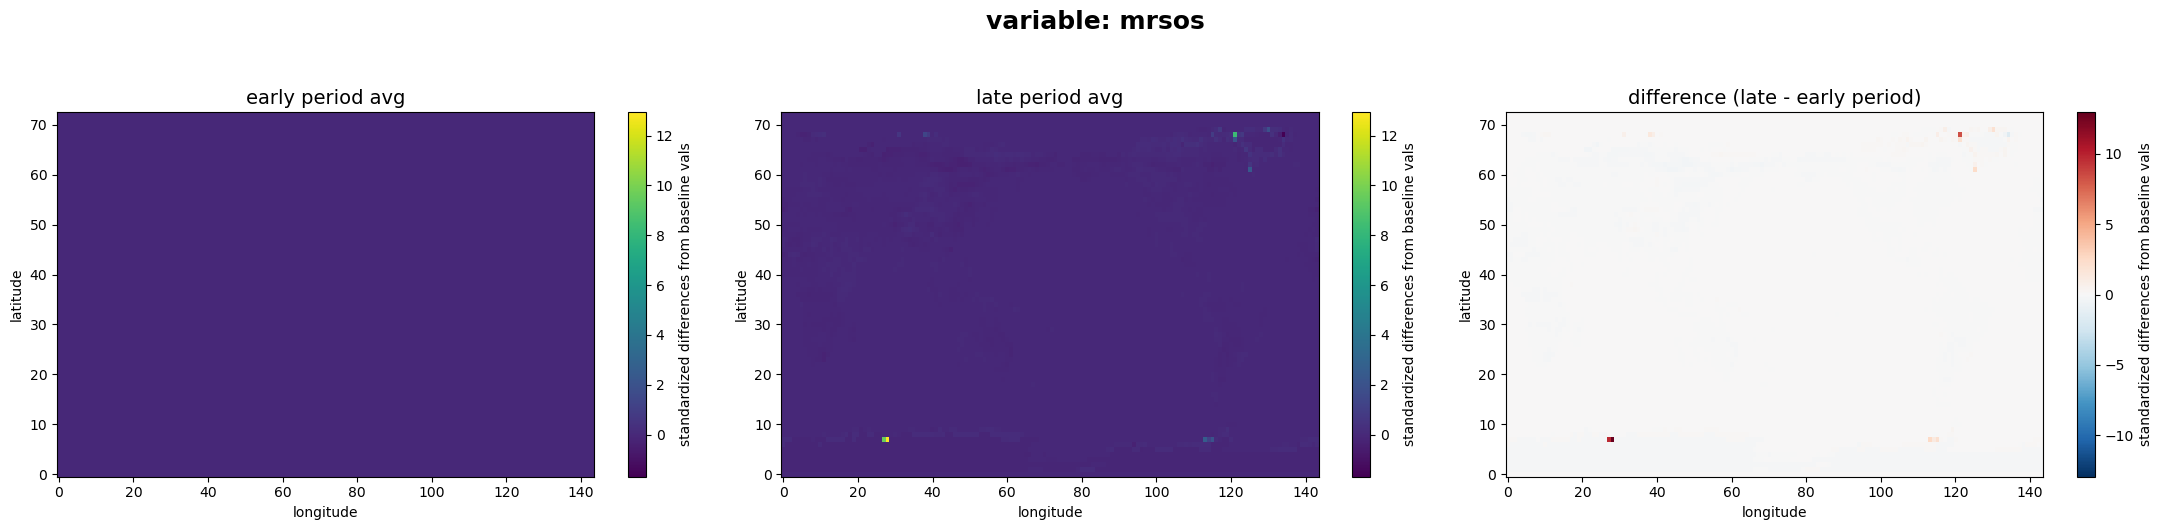

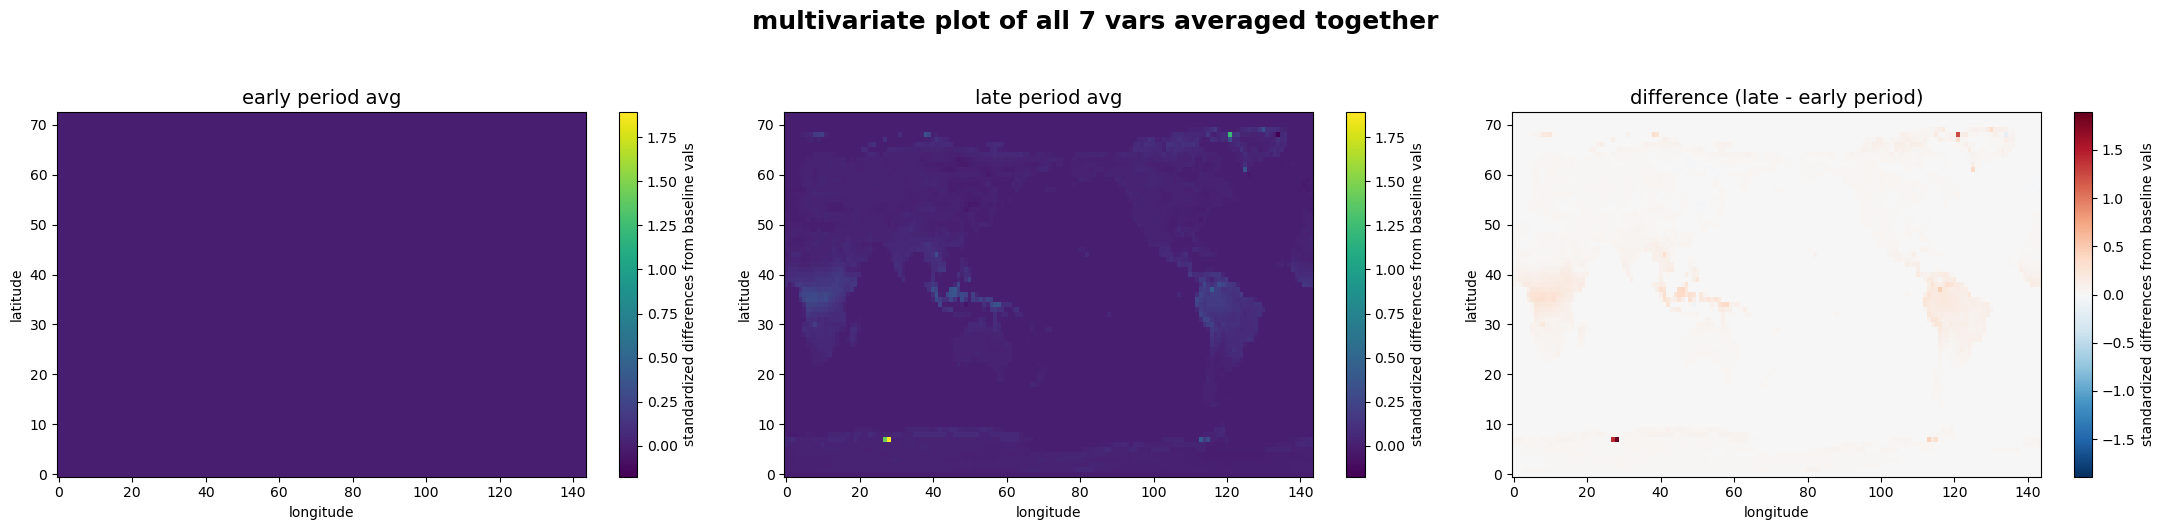

processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_32566/1149981826.py:92: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_32566/1149981826.py:116: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


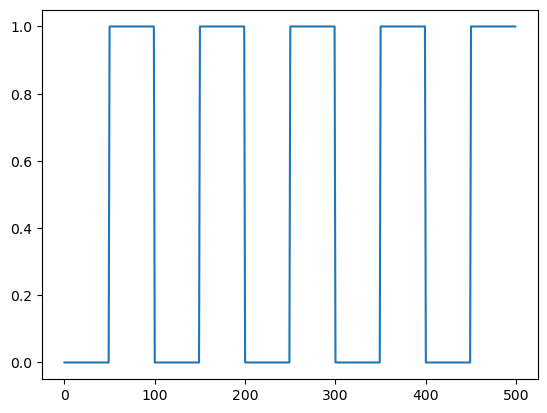

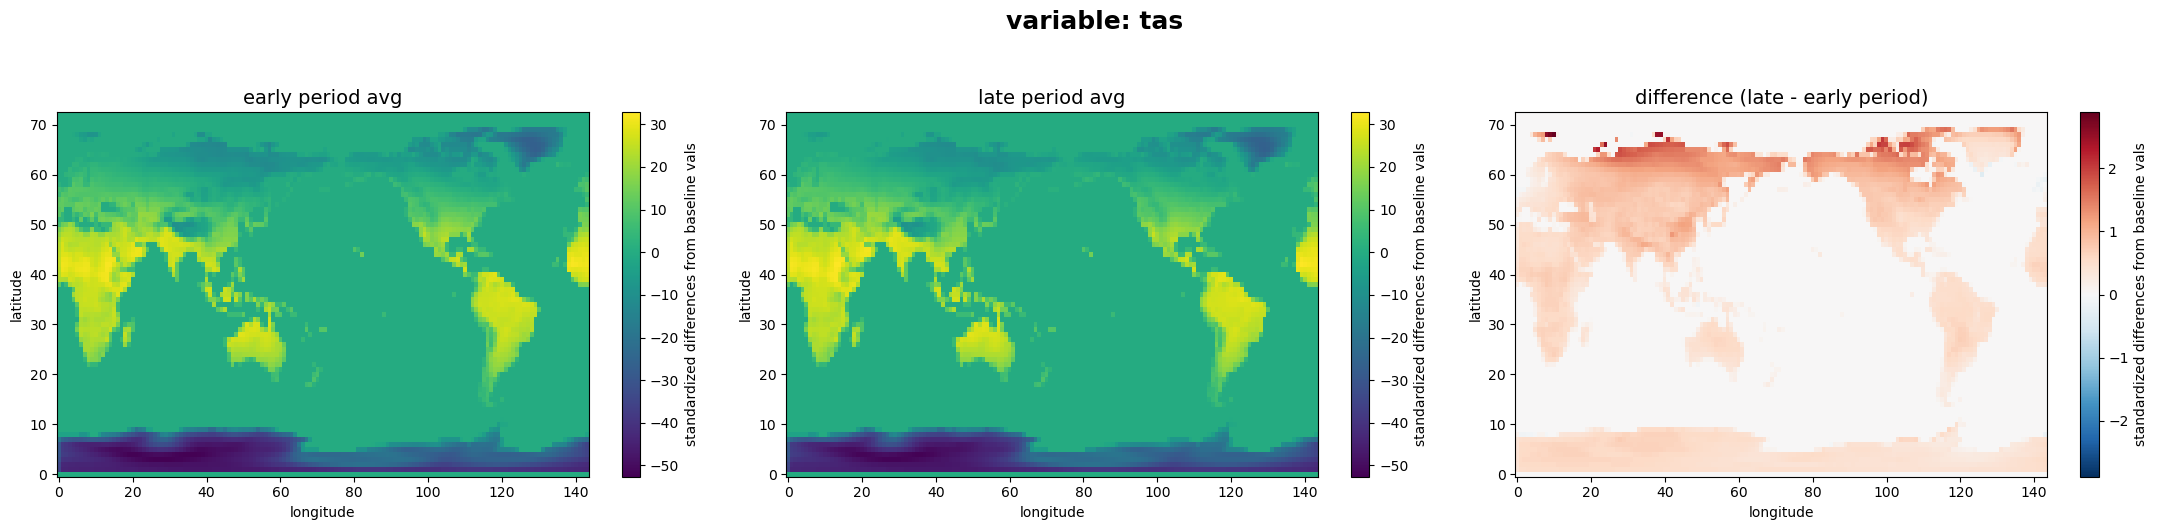

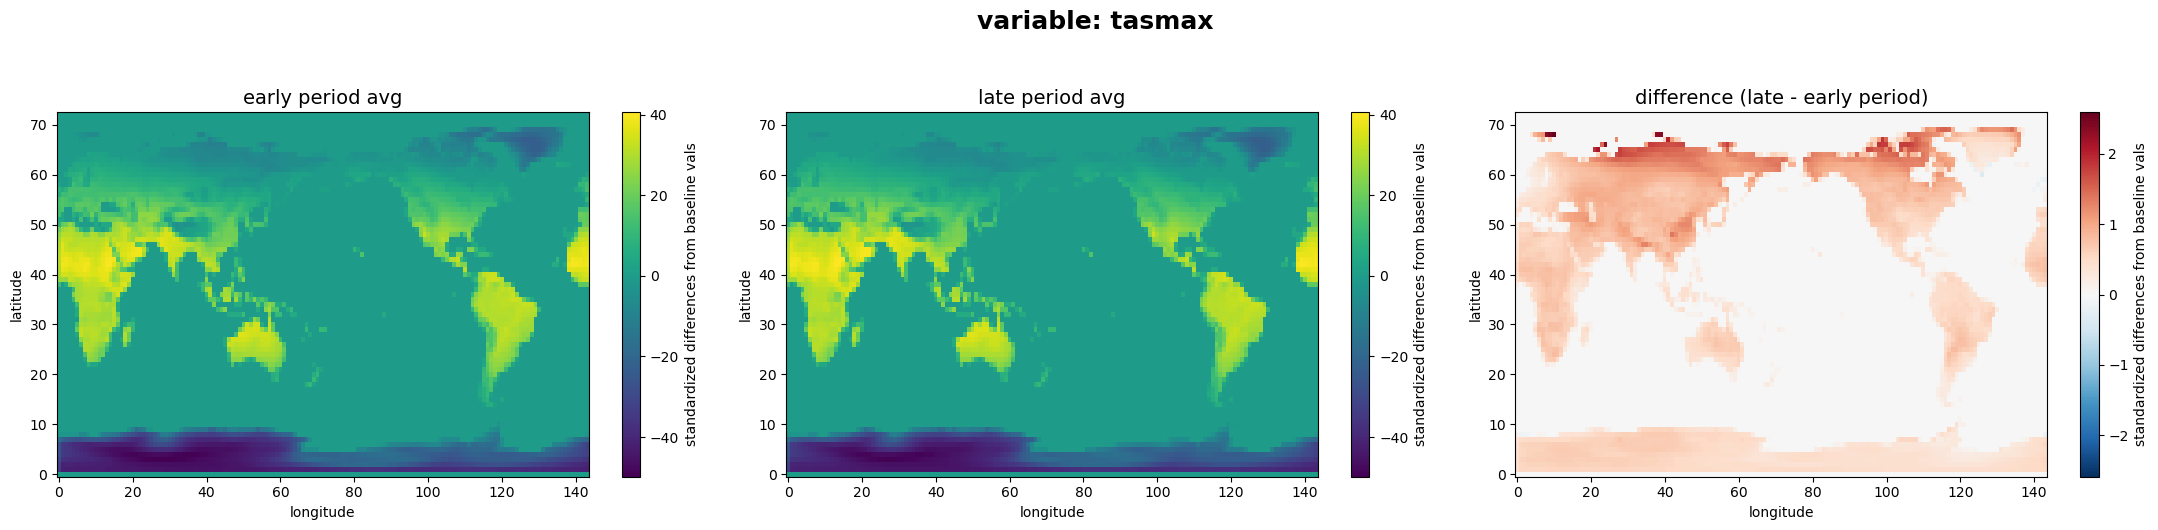

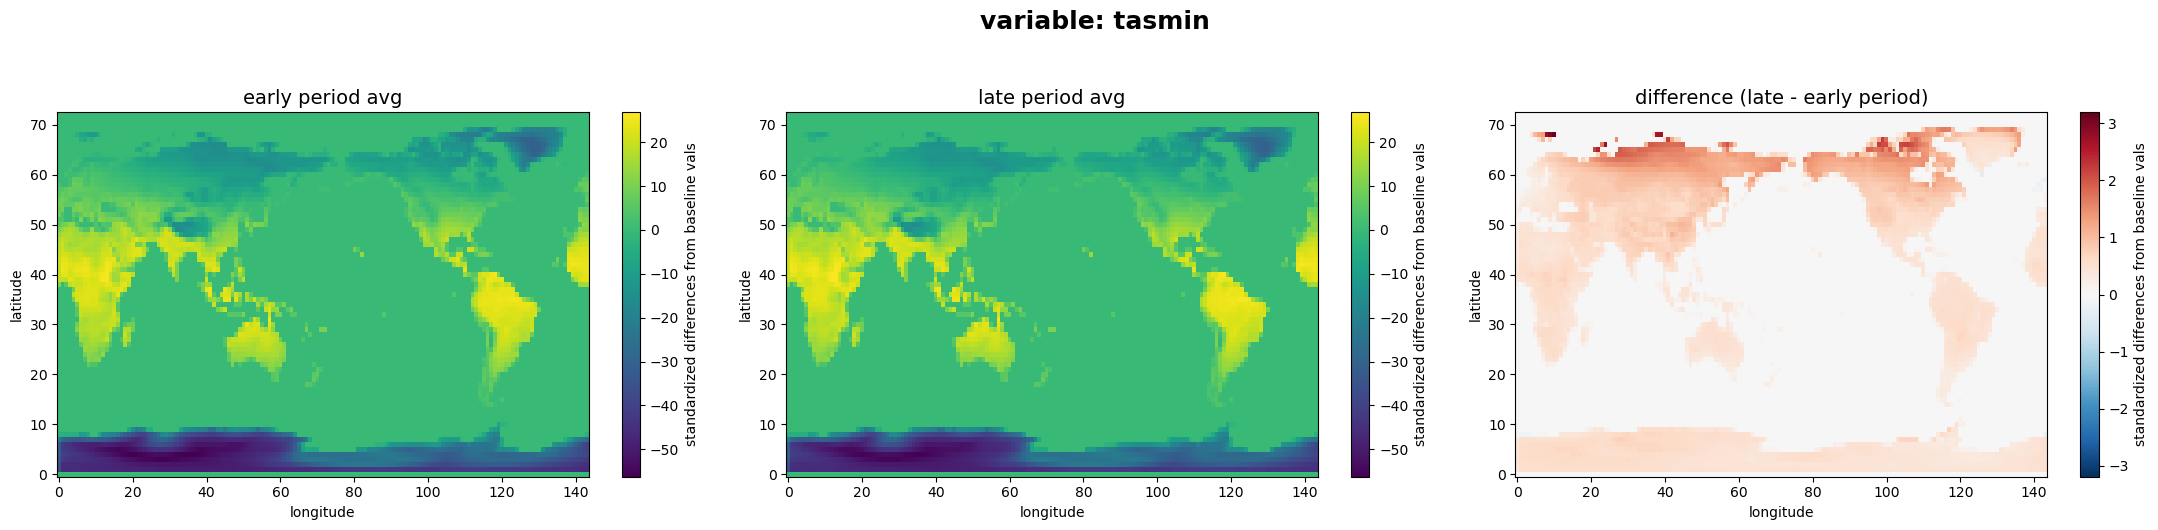

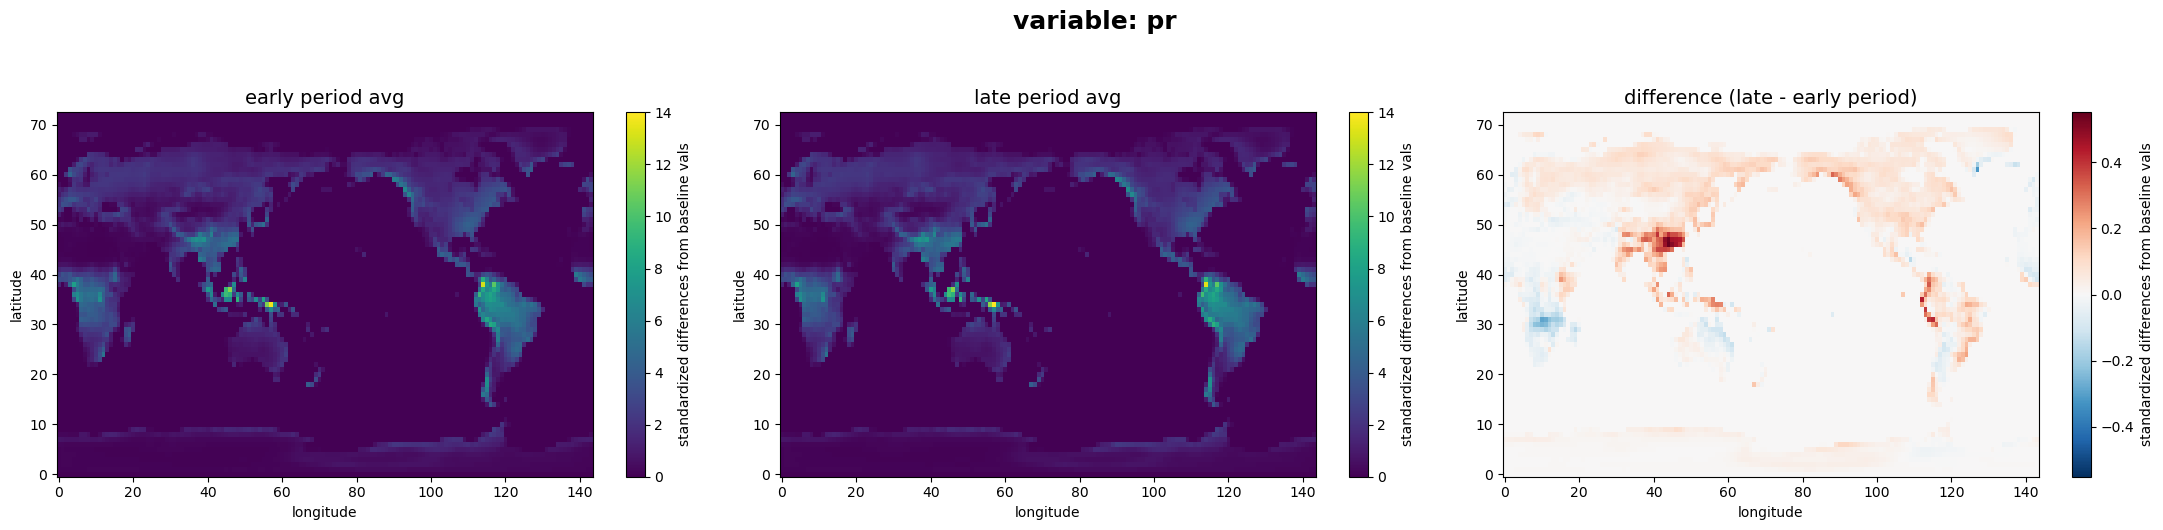

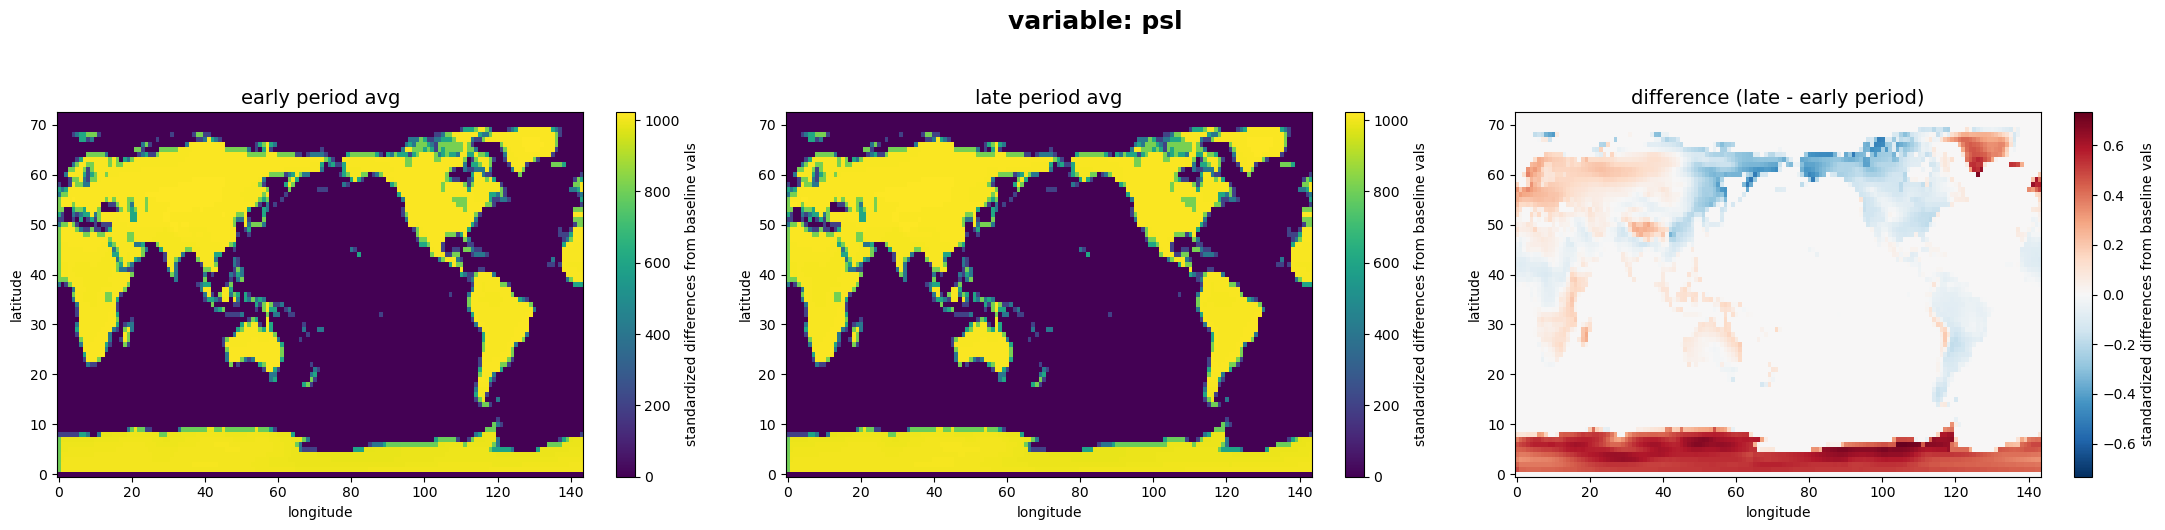

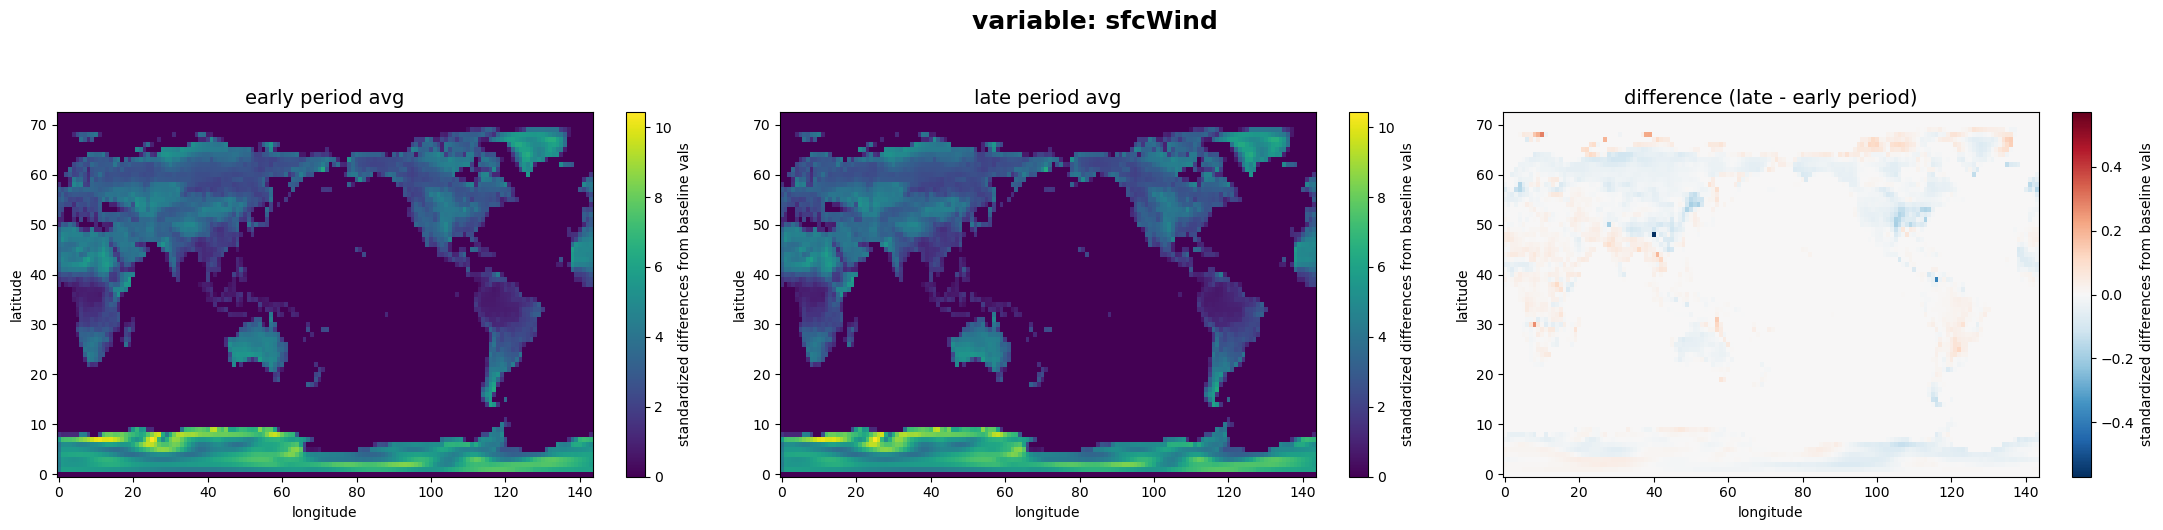

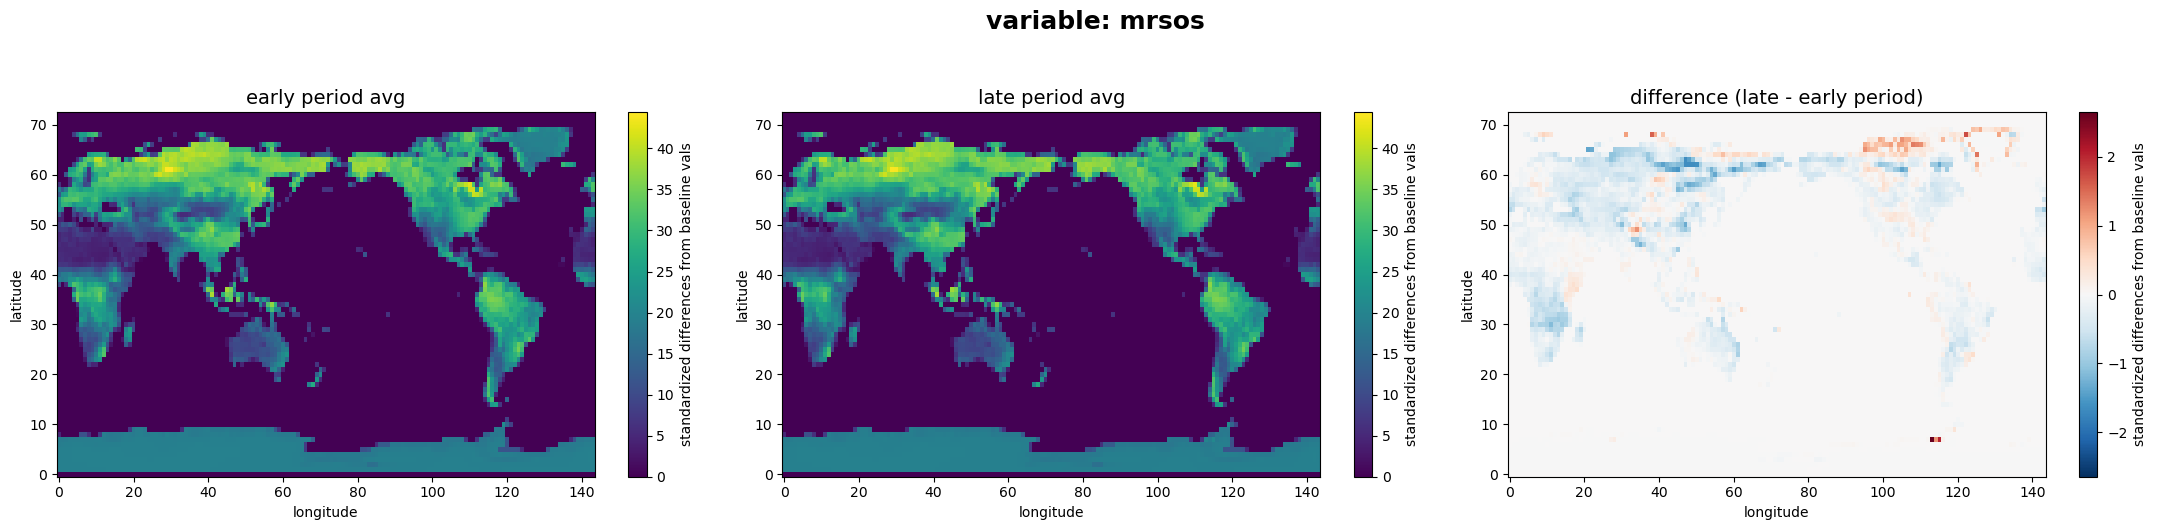

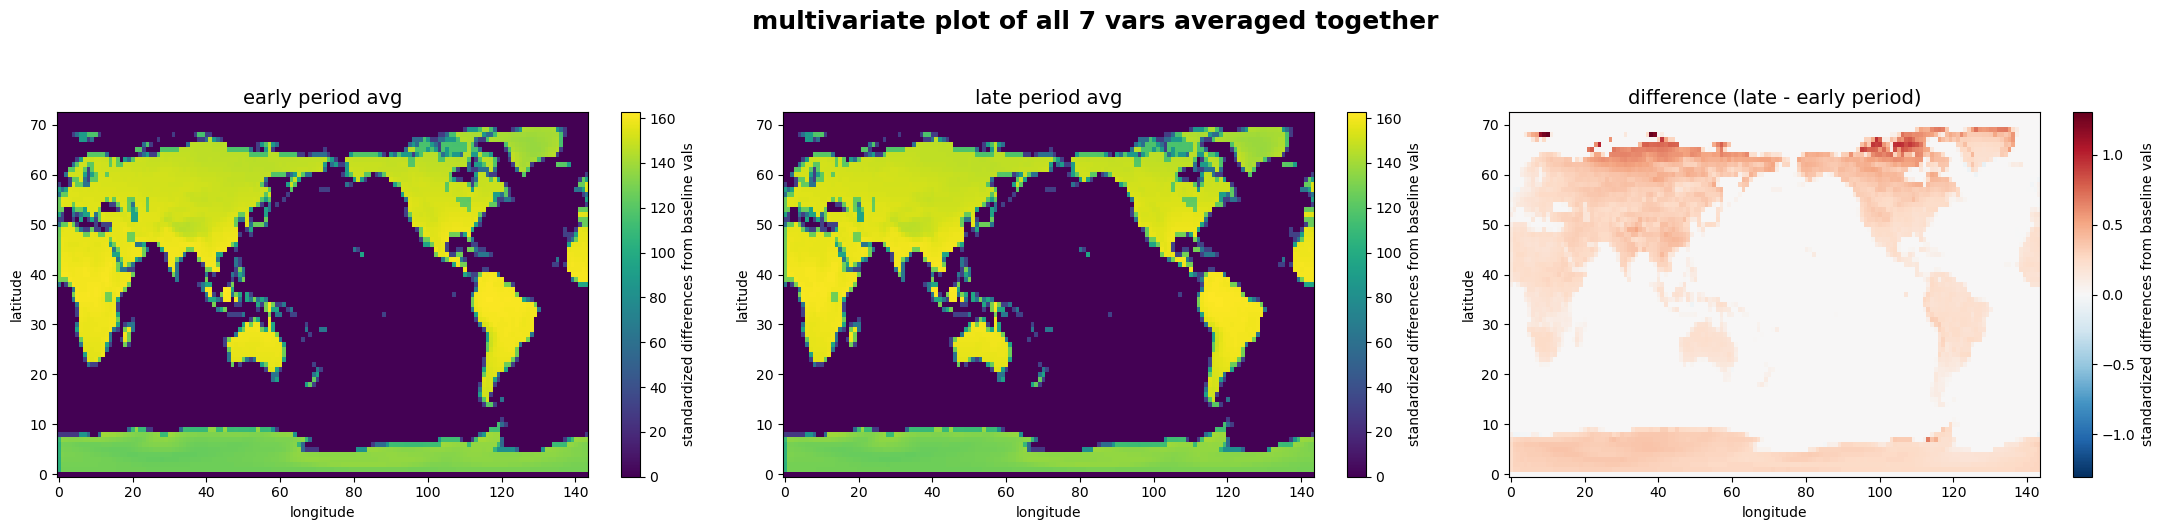

In [1]:
%run "/Users/sophiekim/Desktop/2_research/MamalakisResearch/data_prep_viz/prep/get_cnn_data_v3_sk.ipynb"

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


In [3]:
x_data, y_data = get_cnn_tensors(
    model_list=model_list,
    scenario="ssp126",
    data_path=data_path,         
    use_anomaly=True,  
    stat="mean",
    st_early=2015, end_early=2024,
    st_late=2055, end_late=2064
)

print(x_data.shape, y_data.shape)


processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_32566/1149981826.py:92: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_32566/1149981826.py:116: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
(500, 7, 144, 73) (500, 1)


In [4]:
X = np.transpose(x_data, (0, 2, 3, 1))  # (N, lat, lon, 1)
y = y_data.astype(np.float32)           # (N, 1)

print("X:", X.shape, "y:", y.shape) # FIX 2: SHOULD BE (500,144,73,7) and (500,1)

X: (500, 144, 73, 7) y: (500, 1)


Reason for transposing: From get_cnn_tensors, my raw tensor shape was (1000, 1, 144, 73). This means 1000 samples, 1 channel, 144 latitude, 73 longitude. However, TensorFlow expects (1000 ,144, 73, 1) format. This is ensuring that my CNN sees [lat,lon] as the 2D image. 

In [5]:
# choose random values for splits rather than setting random state
# 1) test = 50
X_rem, X_test, y_rem, y_test = train_test_split(
    X, y,
    test_size=50,
    #random_state=42,
    stratify=y
)

# 2) val = 50 (from remaining 450)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem,
    test_size=50,
    #random_state=42,
    stratify=y_rem
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Class balance:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (400, 144, 73, 7) Val: (50, 144, 73, 7) Test: (50, 144, 73, 7)
Class balance: 0.5 0.5 0.5


In [6]:
def nan_report(name, arr):
    frac = np.isnan(arr).mean()
    print(f"{name}: any NaNs? {np.isnan(arr).any()} | frac NaNs = {frac:.6f}")

nan_report("X_train", X_train)
nan_report("X_val", X_val)
nan_report("X_test", X_test)


X_train: any NaNs? False | frac NaNs = 0.000000
X_val: any NaNs? False | frac NaNs = 0.000000
X_test: any NaNs? False | frac NaNs = 0.000000


## Medium Architecture (~92k parameters)

In [7]:
np.mean(X_test)

0.011617018858607895

In [8]:
tf.keras.utils.set_random_seed(42) 

lat, lon = X_train.shape[1], X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)), # FIX #1: SHOULD BE A 7 (lat,lon,7)

    # CNN block (64 filters) with two convs, then pool
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


2026-04-05 21:17:54.445053: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-05 21:17:54.445370: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-05 21:17:54.446132: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-05 21:17:54.446211: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-05 21:17:54.446583: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 144, 73, 64)    │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 144, 73, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 72, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 36, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 18, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 9, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 9, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 9, 8)       │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        14,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,395 (360.92 KB)

 Trainable params: 92,395 (360.92 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 3/21 edit: increased LR and batch size


Epoch 1/100


2026-04-05 21:17:59.517816: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step - accuracy: 0.6375 - loss: 0.6905 - val_accuracy: 0.7000 - val_loss: 0.6779
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.5525 - loss: 0.6744 - val_accuracy: 0.5200 - val_loss: 0.6532
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.5250 - loss: 0.6473 - val_accuracy: 0.5200 - val_loss: 0.6133
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.5325 - loss: 0.6061 - val_accuracy: 0.5400 - val_loss: 0.5647
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.5775 - loss: 0.5605 - val_accuracy: 0.6400 - val_loss: 0.5235
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.6825 - loss: 0.5250 - val_accuracy: 0.7200 - val_loss: 0.4970
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.7475 - loss: 0.5026 - val_accuracy: 0.7400 - val_loss: 0.4820
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 0.7875 - loss: 0.4875 - val_accuracy: 0.8000 - val_loss: 0.4

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 1.0


In [11]:
#.............................................
# SAVE THE TRAINED NETWORK
#.............................................

#model.save('my_medium_cnn.keras') # or can do .h5 

In [11]:
# giving model an input of all zeroes to see what it would predict if everything was 0 -- like a baseline situation
model.predict(X_test[0:1]*0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


array([[0.0305321]], dtype=float32)

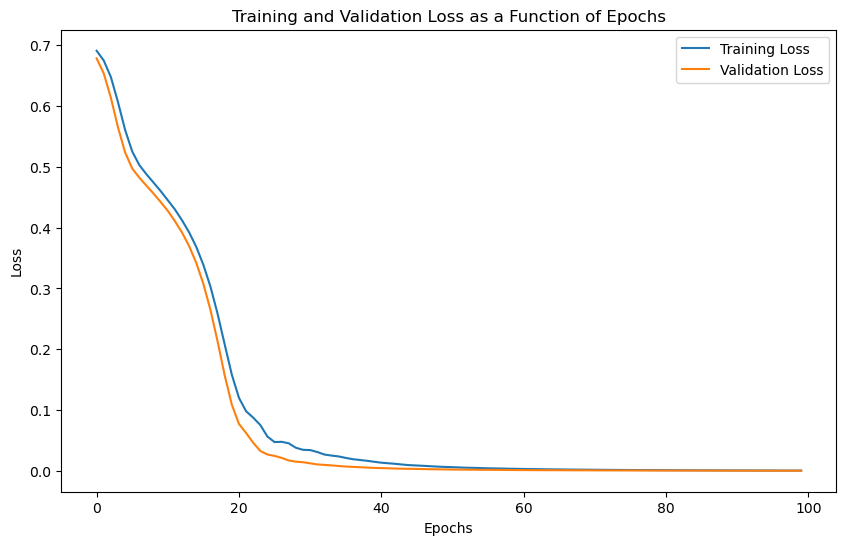

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


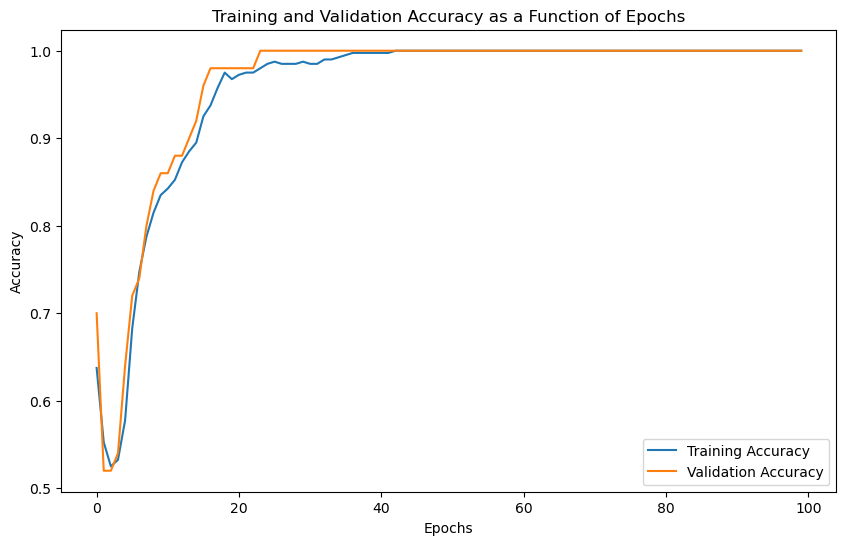

In [14]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## ***importing stuff (was having trouble before)***

In [15]:
import sys
# This ensures we use the exact same Python path as your notebook
!{sys.executable} -m pip install --no-cache-dir pyproj cartopy "shapely<2.0"

✅ SUCCESS!
PyProj: 3.7.1
Shapely: 1.8.5.post1


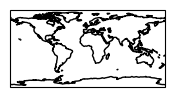

🌍 Map rendered! You are ready to plot.


In [16]:
try:
    import pyproj
    import cartopy.crs as ccrs
    import shapely
    print(f"✅ SUCCESS!")
    print(f"PyProj: {pyproj.__version__}")
    print(f"Shapely: {shapely.__version__}")
    
    # The ultimate test: can it handle a projection?
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(2, 2))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    plt.show()
    print("🌍 Map rendered! You are ready to plot.")
except Exception as e:
    print(f"❌ Still missing a piece: {e}")

## **PLOTS**

In [17]:
# Plotting figures
import matplotlib.pyplot as plt #Main plotting package
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker

In [18]:

# Get lat and lon from opening any ds
file_path = data_path + '/CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc'
ds = nc.Dataset(file_path)
lat = np.array(ds["lat"][:]) # extracting latitude and longitude grids
lon = np.array(ds["lon"][:])

In [19]:
var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]


# **NEW**

In [20]:
# baseline calculation


# indexing out where the early periods are in the train set 
early_idx = np.where(y_train == 0)[0]

# getting first 200 
first_200_early_idx = early_idx[:200]

# getting baseline values using the row indices and indexing out the train set
baseline = X_train[first_200_early_idx]

# getting baseline averages across the sample values (axis 0) and keeping the rest of the dimensional structure
baseline_mean = np.mean(baseline, axis=0, keepdims=True)

In [21]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    return grads


def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    # 1. Ensure inputs and baseline are float32
    inputs = inputs.astype(np.float32)
    
    if baseline is None:
        # Fallback to zeros if no baseline provided
        baseline = np.zeros_like(inputs).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)
        # Ensure baseline has a leading dimension if it's a single mean map
        if baseline.ndim == inputs.ndim - 1:
            baseline = np.expand_dims(baseline, axis=0)

    # 2. Generate interpolation steps
    # We use np.linspace to create the scaling factors (alphas)
    alphas = np.linspace(0.0, 1.0, num_steps + 1)
    
    # 3. Compute Gradients along the path
    # We iterate through the interpolation path from baseline to input
    all_grads = []
    for alpha in alphas:
        # Interpolate: baseline + alpha * (input - baseline)
        step_input = baseline + alpha * (inputs - baseline)
        
        # Get gradients for this specific step
        grad = get_gradients(step_input, model, top_pred_idx=top_pred_idx)
        all_grads.append(grad)
    
    # 4. Convert to tensor for averaging
    # Shape: (num_steps + 1, batch, vars, lat, lon)
    all_grads = tf.convert_to_tensor(all_grads, dtype=tf.float32)

    # 5. Approximate the integral (Trapezoidal Rule)
    # Average the gradients of adjacent steps
    grads_at_step_ends = (all_grads[:-1] + all_grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_at_step_ends, axis=0)

    # 6. Final IG calculation: (input - baseline) * average gradient
    integrated_grads = (inputs - baseline) * avg_grads.numpy()
    
    return integrated_grads

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
--- Analysis for Sample #5 ---
Ground Truth: 0.0000
Prediction:   0.0000
Difference:   0.0000
-----------------------------------


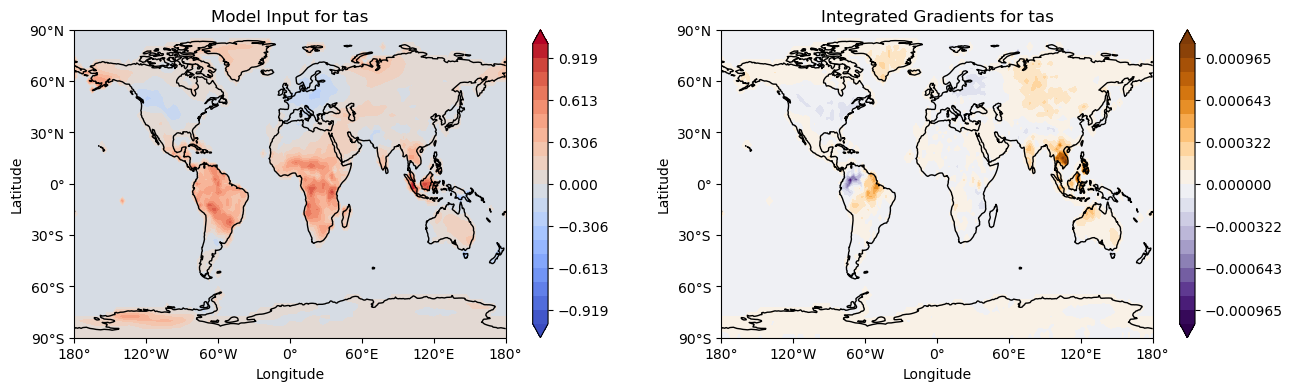

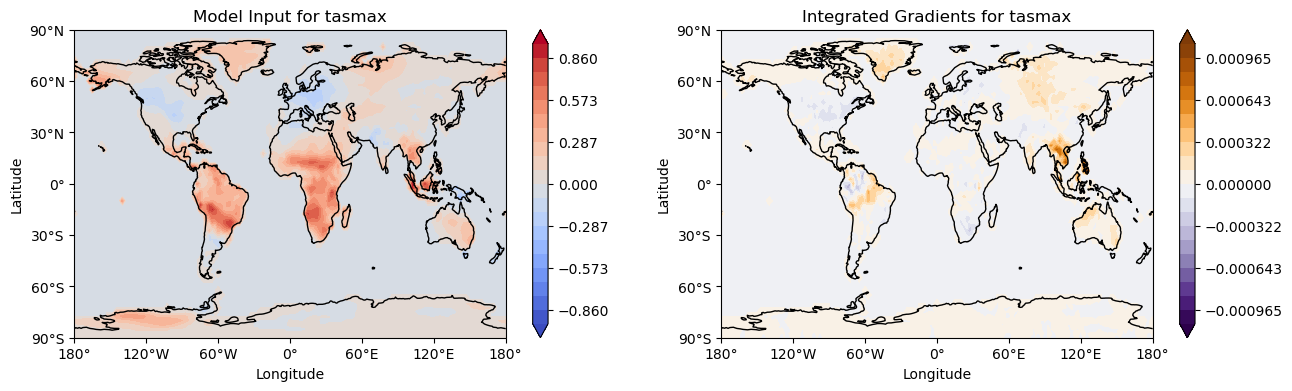

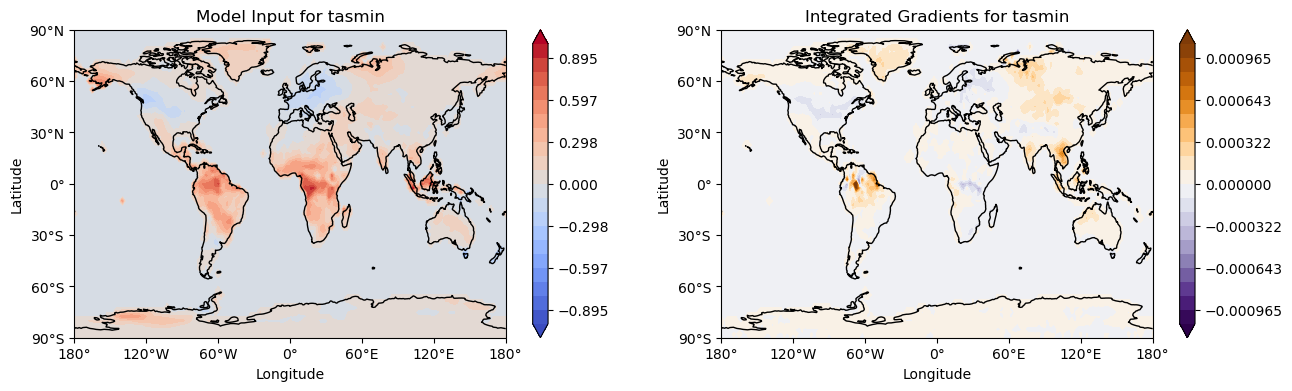

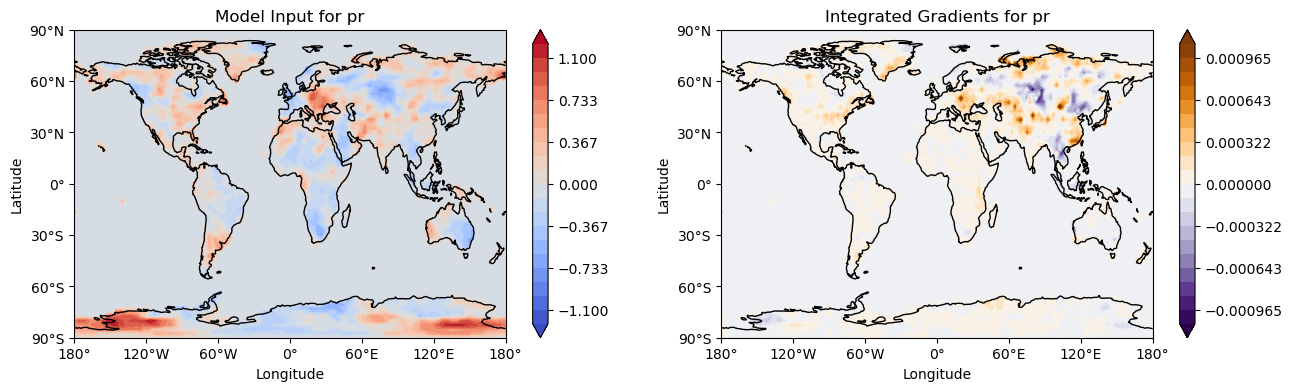

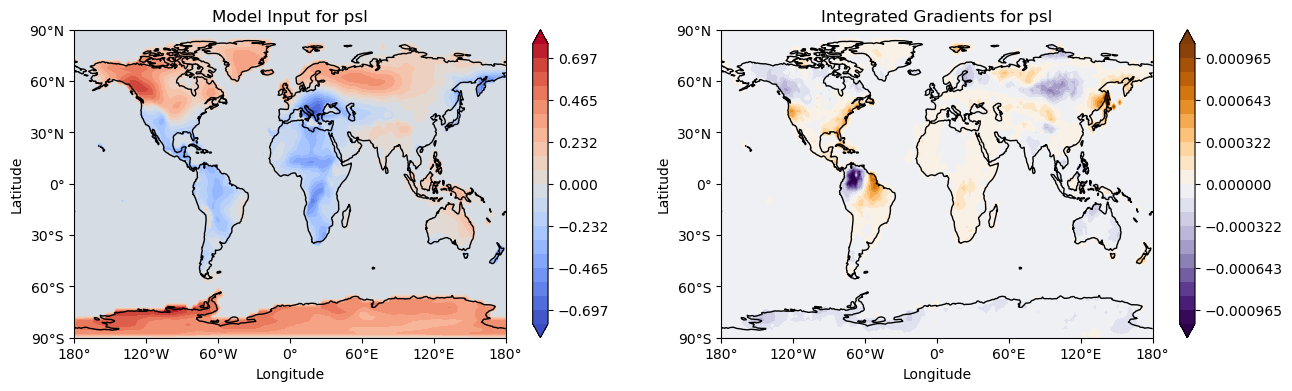

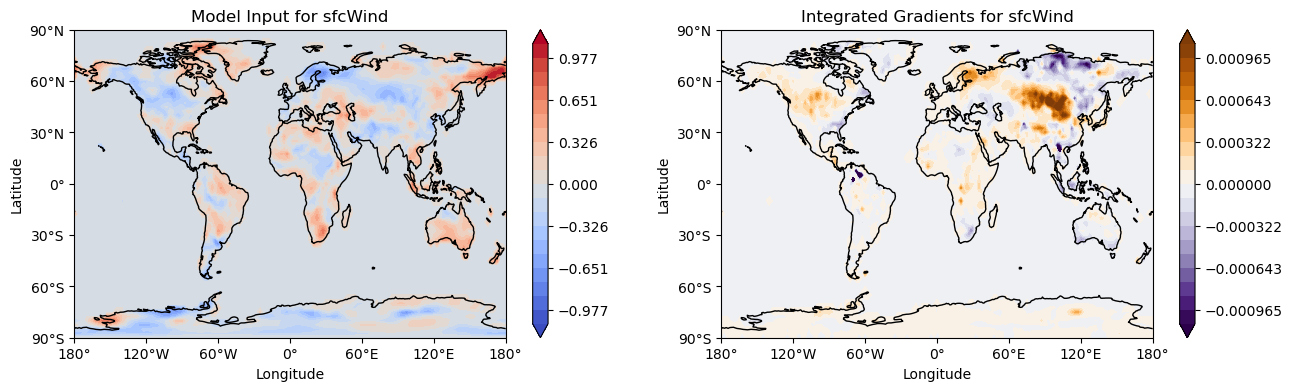

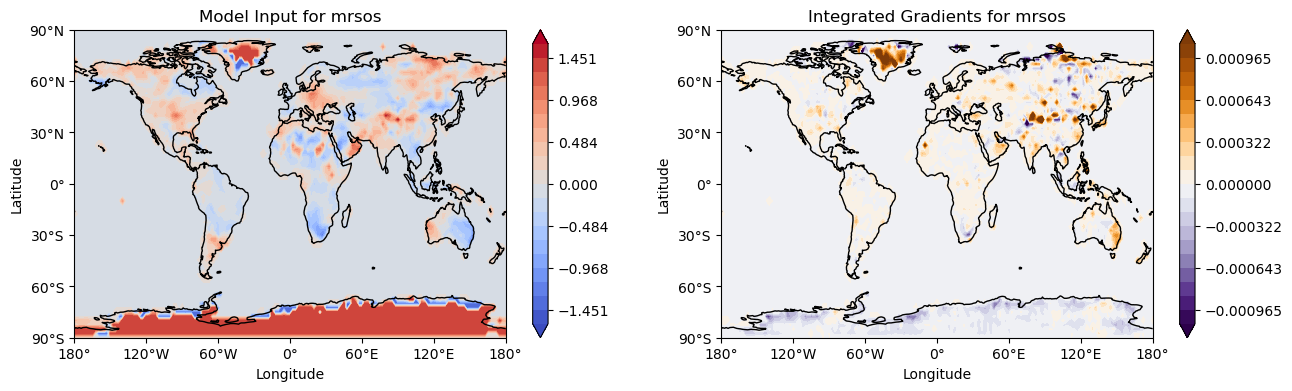

In [23]:
def explain_pred(sample_idx):
    # getting preds and truth vals 
    y_pred = model.predict(X_test[sample_idx:sample_idx+1])[0][0]
    y_true = y_test[sample_idx].item()
    
    IntegratedGrad_zeros_heatmap=get_integrated_gradients(X_test[sample_idx:sample_idx+1],model, np.mean(X_train[np.where(y_train==0), :, :, :], axis=0)) # used baseline of averaged early period in training set

    print(f"--- Analysis for Sample #{sample_idx} ---")
    print(f"Ground Truth: {y_true:.4f}")
    print(f"Prediction:   {y_pred:.4f}")
    print(f"Difference:   {abs(y_true - y_pred):.4f}")
    print("-" * 35)

    X_test_xai = np.transpose(X_test,(0,2,1,3)) # changes X_test
    IntegratedGrad_zeros_heatmap = np.transpose(IntegratedGrad_zeros_heatmap,(0,2,1,3))
    ig_max = np.quantile(np.abs(IntegratedGrad_zeros_heatmap.flatten()), 0.99)

    # making plots for the 7 vars for the sample given by user
    for i in range(len(var_list)):
        
        data_slice = X_test_xai[sample_idx, :, :, i]
        samplep, lonp = add_cyclic_point(data_slice, coord=lon)
        plt.figure(figsize=(32,4))
        ax=plt.subplot(1,4,1,projection=ccrs.PlateCarree())
        cs = plt.contourf(lonp, lat, samplep, cmap ="coolwarm",levels = np.linspace(-np.max(np.abs(data_slice),axis=(0,1)),np.max(np.abs(data_slice),axis=(0,1)),21),extend = 'both')  
        cbar = plt.colorbar(cs)   
        plt.title(f'Model Input for {var_list[i]}') 
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.axis('tight')
        ax.coastlines()
        #plt.legend()
        # Define the xticks for longitude
        ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # Define the yticks for latitude
        ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)

        ax=plt.subplot(1,4,2,projection=ccrs.PlateCarree())
        samplep,lonp = add_cyclic_point(IntegratedGrad_zeros_heatmap[0,:,:,i], coord=lon)
        cs = plt.contourf(lonp, lat, samplep, cmap ="PuOr_r",levels = np.linspace(-ig_max, ig_max, 21), extend = 'both')  
        cbar = plt.colorbar(cs)   
        plt.title(f'Integrated Gradients for {var_list[i]}') 
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.axis('tight')
        ax.coastlines()
        #plt.legend()
        # Define the xticks for longitude
        ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # Define the yticks for latitude
        ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)
        plt.show()

# for sample 5
explain_pred(5)

In [24]:
def run_full_climate_evaluation(model, X_train, y_train, X_test, y_test, var_list, lat, lon):

    # getting predictions and test accuracy 
    y_pred_probs = model.predict(X_test).flatten()
    test_accuracy = np.mean((y_pred_probs > 0.5).astype(int) == y_test.flatten())

    # getting baseline values (aka the first 200 samples of the early period)
    early_idx = np.where(y_train == 0)[0]
    baseline = np.mean(X_train[early_idx], axis=0, keepdims=True)
    

    late_idx = np.where(y_test == 1)[0]

    # getting integrated gradients based on the baseline above 
        # FIND SHAPE -- split of early/late periods
    ig_heatmaps = get_integrated_gradients(X_test[late_idx], model, baseline)
    print(ig_heatmaps.shape)
    # ensuring heatmaps are numpy 
    if hasattr(ig_heatmaps, 'numpy'): ig_heatmaps = ig_heatmaps.numpy()

    # getting variable importance 
        # absolute value to capture magnitude rather than early (neg) & late (pos) cancellling each other out
        # averaging across all samples (0), lat (1), lon (2)
    var_import = np.mean(np.abs(ig_heatmaps), axis=(0, 1, 2))
    # seeing where on the map importance is 
        # averaging only over the samples --> averaging across diff yrs/ensemble members rather than looking at each sample 
    var_spatial = np.mean(np.abs(ig_heatmaps), axis=0)
    
    # pulling the max values for the total map for regional importance so it shows up better 
        # could do average tho, or quantile? 
    reg_import = np.max(np.abs(ig_heatmaps), axis=(0, 3)) 


    # PLOTTING FIGURE SET UP
    
    # initializing number of plots variable by adding 3 (for scatter, variable importance bar, total regional importance) and then how many variables 
    num_plots = 3 + len(var_list)
    # width of 12, height of 6 multiplied by number of plots
    fig = plt.figure(figsize=(12, 6 * num_plots))



    # PLOT 1 - scatterplot of error magnitude 
    ax1 = plt.subplot(num_plots, 1, 1)
    
    all_preds = model.predict(X_test).flatten()
    all_truth = y_test.flatten()
    
    # getting absolute error magnitude by subtracting predictions from the real values
    errors = np.abs(all_preds - all_truth)
    
    # initializing scatter plot to compare the truth and predictions with color as the magnitude of error 
    sc = ax1.scatter(all_truth, all_preds, c=errors, cmap='viridis', 
                     alpha=0.6, s=15, edgecolors='none')
    
    # adding colorbar based on absolute error
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label('Absolute Error Magnitude', fontsize=12)

    ax1.set_xlabel('Ground Truth (Actual)', fontsize=12)
    ax1.set_ylabel('Model Prediction', fontsize=12)
    ax1.set_title(f'Climate Performance: Error Distribution (Acc: {test_accuracy:.2%})', fontsize=14)
    ax1.grid(True, alpha=0.2)



    # BAR PLOT - variable importance measurement 
    ax2 = plt.subplot(num_plots, 1, 2)
    # sorted_idx stores the indice values of a hypothetically sorted var_import 
    sorted_idx = np.argsort(var_import)

    # making bar plot 
        # y value is the variable name in the order of the sorted var_import
        # x value is the actual importance value 
    ax2.barh(np.array(var_list)[sorted_idx], var_import[sorted_idx], color='green')
    ax2.set_title("Global Variable Importance", fontsize=16)

    # TOTAL REGIONAL IMPORTANCE MAP  so i guess global 
    ax3 = plt.subplot(num_plots, 1, 3, projection=ccrs.PlateCarree())
    # ensuring lat/lon dimensions are in the right order
    data_total = reg_import if reg_import.shape == (len(lat), len(lon)) else reg_import.T
    # this makes the coordinates correct -- puts first column at the end of the array so that it doesnt have a seam gap 
        # sp_t is the wider array 
        # lp_t is the longitude coords
    sp_t, lp_t = add_cyclic_point(data_total, coord=lon)

    # lp_t = x axis (longitude) 
    # lat = y axis (latitude)
    # sp_t = importance values (height/importance of signal)
    # level is the smoothness/steps of the color gradient 
    cs_t = ax3.contourf(lp_t, lat, sp_t, cmap="YlOrRd", levels=20)
    ax3.coastlines()
    ax3.set_title("MAX Spatial Importance (Combined)", fontsize=16)
    plt.colorbar(cs_t, ax=ax3, orientation='vertical', pad=0.02, shrink=0.8)


    # REGIONAL IMPORTANCE FOR EACH VAR

    # initializing a max colorbar value to make colorbar scale the same for all vars 
    global_vmax = np.quantile(np.abs(var_spatial), 0.99)
    # getting indices for the variables from largest to smallest (what the -1 is)
    top_vars = np.argsort(var_import)[::-1]
    # looping through each item in the top_vars and mapping that 
    for i, v_idx in enumerate(top_vars):
        ax = plt.subplot(num_plots, 1, i + 4, projection=ccrs.PlateCarree())
        # ensuring that the plot is in correct lat/lon format 
        data_v = var_spatial[:, :, v_idx]
        if data_v.shape == (len(lon), len(lat)): data_v = data_v.T
        
        samplep, lonp = add_cyclic_point(data_v, coord=lon)
        vmax = np.quantile(np.abs(data_v), 0.99)
        if vmax <= 1e-12: vmax = 0.1
        
        cs = ax.contourf(lonp, lat, samplep, cmap="coolwarm", 
                         levels=np.linspace(0, global_vmax, 21), extend='both')
        
        # formatting
        ax.coastlines()
        ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
        ax.set_title(f'Importance: {var_list[v_idx]}', fontsize=16)
        plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)

    plt.tight_layout()
    plt.show()
    return {"accuracy": test_accuracy, "var_importance": dict(zip(var_list, var_import))}

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step
(25, 144, 73, 7)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


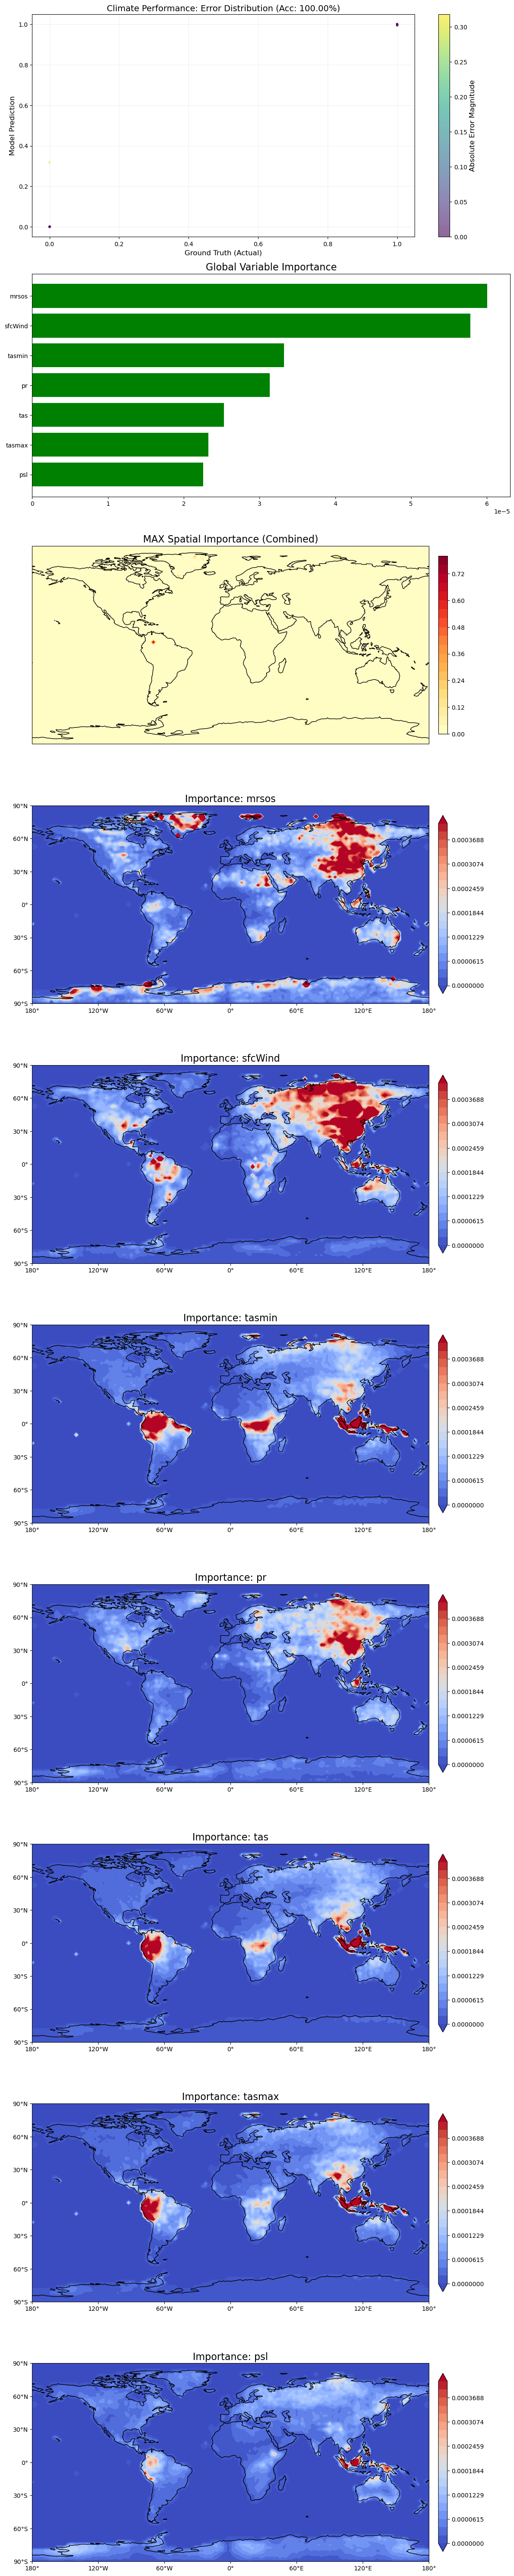

In [25]:
results = run_full_climate_evaluation(model, X_train, y_train, X_test, y_test, var_list, lat, lon)

In [ ]:
# 2085 - 2094 = last time 

In [ ]:
def cnn_training(X_data, y_data, learning_rate=0.001, epochs=200, batch_size=64):
    X = np.transpose(X_data, (0, 2, 3, 1))  # (N, lat, lon, 7)
    y = y_data.astype(np.float32)           # (N, 1)

    # choose random values for splits rather than setting random state
    # 1) test = 50
    X_rem, X_test, y_rem, y_test = train_test_split(
        X, y,
        test_size=50,
        #random_state=42,
        stratify=y
    )

    # 2) val = 50 (from remaining 450)
    X_train, X_val, y_train, y_val = train_test_split(
        X_rem, y_rem,
        test_size=50,
        #random_state=42,
        stratify=y_rem
    )

    lat, lon = X_train.shape[1], X_train.shape[2]

    model = models.Sequential([
        layers.Input(shape=(lat, lon, 7)), # FIX #1: SHOULD BE A 7 (lat,lon,7)

        # CNN block (64 filters) with two convs, then pool
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

        # CNN block 32 kernels (conv + pool)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

        # CNN block 16 kernels (conv only)
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),             
        layers.Dense(50, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])


    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # MAKE TEST_INDICES LATER
    
    return model, X_train, y_train, X_test, y_test, test_indices

In [ ]:
y_pred_probs = np.empty(50,1)
y_test_matrix = np.empty(50,1)
ig_heatmaps = np.empty(35, 144, 73, 7, 1)
test_indices = np.empty(50,) # 50 by whatever number of models 
meta_data = np.empty # should save the scenario, early period yrs, late period yrs

for scenario in ['ssp119', 'ssp126']:
    for early_per_start_yr in [2015, 2025, 2035, 2045, 2055, 2065, 2075, 2085]:
        for late_per_start_yr in np.arange(early_per_start_yr+10, 2085, 10):
            # grab data 
            X_data, y_data = get_cnn_tensors(model_list, scenario, data_path, st_early=early_per_start_yr, end_early=early_per_start_yr+9, st_late=late_per_start_yr, end_late=late_per_start_yr+9)
            # train CNN -- aka train/test split etc 
            model, X_train, y_train, X_test, y_test, test_indices = cnn_training(X_data, y_data)

            # getting predictions and test accuracy 
            y_pred_probs = np.concatenate(y_pred_probs, model.predict(X_test).flatten(), axis=1)
            y_test_matrix = np.concatenate(y_test_matrix, y_test, axis=1)

            # getting baseline values (aka the first 200 samples of the early period)
            early_idx = np.where(y_train == 0)[0]
            baseline = np.mean(X_train[early_idx], axis=0, keepdims=True)
            late_idx = np.where(y_test == 1)[0]

            

            # getting integrated gradients based on the baseline above 
                # FIND SHAPE -- split of early/late periods
            ig_heatmaps_temp = get_integrated_gradients(X_test[late_idx], model, baseline)

            # ensuring heatmaps are numpy 
            if hasattr(ig_heatmaps_temp, 'numpy'): ig_heatmaps_temp = ig_heatmaps_temp.numpy()
            ig_temp = np.zeros(35, 144, 73, 7, 1)
            ig_temp[0:len(late_idx)] = ig_heatmaps_temp
            ig_heatmaps = np.concatenate(ig_heatmaps, ig_temp, axis=4)

# ENSURE TO SAVE DATA AT THE END! like export_csv something like that 
    # or netcdf or whatever 
            